# APT Relocation — ESP Pipeline Run Validation

This notebook validates the **ESP relocated APTs**. The relocation was produced by the
`apa_reloaction_pipeline` job run on `dbw-arc-merone-pipeline-dev` (screenshot below):
the pipeline runs `copy_esp_apt` → `zip_extraction` → `load_bfp` → `filter_apt_already_in_bfp`
→ `move_apt_with_hsn_match` → `generate_csv`, ending with the relocated-APT CSV this notebook reads.

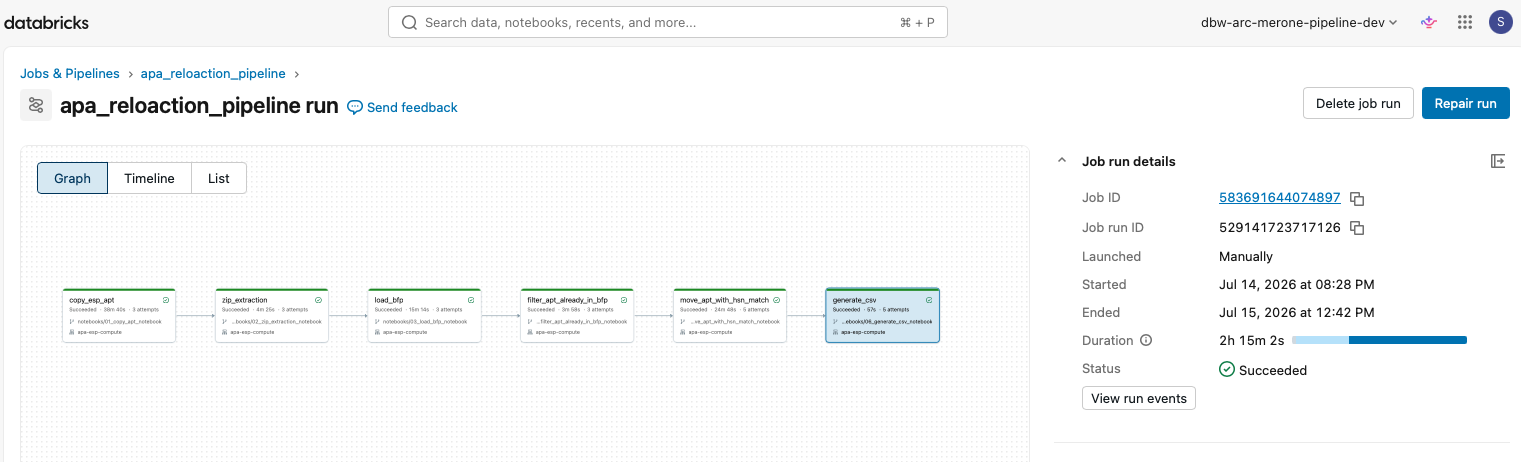


## Validation steps

**Step 1 — Load the relocation CSV**

Read the ESP APT relocation CSV produced by the pipeline's `generate_csv` step:

```
/mnt/aqua/data-correctness/correction-input/SEACO-6290-ESP-Apt-Relocation/relocated_apt_data_prod_ESP_20250207-0001.csv
```

**Step 2 — Compute relocation distance**

Add a column that calculates the distance **in meters** between the original `apt_geometry`
and the relocated `new_apt_geometry`. This is the core validation signal — how far each APT moved.

### Step 1 — Read the APT relocation CSV

The CSV is **pipe-delimited** (`|`) with a header row. Columns:
`apt_id | apt_geometry | new_apt_geometry | bfp_geometry | bfp_id | status | apt_hsn | apt_sn | unsigned_apt_id`.

`apt_geometry` / `new_apt_geometry` / `bfp_geometry` are WKT strings; `apt_id` is an escaped
JSON struct (`layerId` / `high` / `low`) — read as plain strings here (no `inferSchema`, so the
quoted JSON and pipes inside fields are preserved).

In [ ]:
val csvPath = "/mnt/aqua/data-correctness/correction-input/SEACO-6290-ESP-Apt-Relocation/relocated_apt_data_prod_ESP_20250207-0001.csv"

val relocatedDf = spark.read
  .option("header", "true")
  .option("delimiter", "|")
  .option("quote", "\"")
  .option("escape", "\\")
  .csv(csvPath)

relocatedDf.printSchema()

In [ ]:
println(s"Total relocated APT rows: ${relocatedDf.count()}")
display(relocatedDf.limit(10))

### Step 2 — Add relocation distance (meters)

`apt_geometry` / `new_apt_geometry` are WKT point strings in `POINT (lng lat)` form. We parse
lng/lat straight out of the WKT and compute the **Haversine** great-circle distance in **meters**
(rounded to 2 decimals) — pure Spark math, no Sedona. This avoids the Sedona `serialVersionUID` /
`InvalidClassException` classpath mismatch that `ST_DistanceSpheroid` hits on this cluster, and
matches the distance approach used in `RoofTop Regression Scoping`. We also add a `hookline` column
— a `LINESTRING (old -> new)` WKT connecting `apt_geometry` to `new_apt_geometry` for visual QA.

In [ ]:
import org.apache.spark.sql.functions._

// WKT points are "POINT (lng lat)" (X = longitude, Y = latitude). Pull both coords out as doubles.
val pointRegex = """POINT\s*\(\s*(-?\d+(?:\.\d+)?)\s+(-?\d+(?:\.\d+)?)\s*\)"""

val withCoords = relocatedDf
  .withColumn("old_lon", regexp_extract(col("apt_geometry"), pointRegex, 1).cast("double"))
  .withColumn("old_lat", regexp_extract(col("apt_geometry"), pointRegex, 2).cast("double"))
  .withColumn("new_lon", regexp_extract(col("new_apt_geometry"), pointRegex, 1).cast("double"))
  .withColumn("new_lat", regexp_extract(col("new_apt_geometry"), pointRegex, 2).cast("double"))

// Haversine distance in meters (mean earth radius) — avoids Sedona for the distance calc
val EARTH_RADIUS_M = 6371008.8
val dLat = radians(col("new_lat") - col("old_lat"))
val dLon = radians(col("new_lon") - col("old_lon"))
val haversine =
  pow(sin(dLat / 2), 2) +
  cos(radians(col("old_lat"))) * cos(radians(col("new_lat"))) * pow(sin(dLon / 2), 2)

val distanceDf = withCoords
  .withColumn("relocation_distance_meters",
    round(lit(2 * EARTH_RADIUS_M) * asin(sqrt(haversine)), 2))
  // hookline: LINESTRING WKT connecting the old (apt_geometry) and new (new_apt_geometry) points
  .withColumn("hookline",
    concat(lit("LINESTRING("),
      col("old_lon"), lit(" "), col("old_lat"), lit(", "),
      col("new_lon"), lit(" "), col("new_lat"), lit(")")))

display(distanceDf.select("apt_geometry", "new_apt_geometry", "relocation_distance_meters", "hookline").limit(20))

In [ ]:
import org.apache.spark.sql.functions._

// Quick distribution sanity-check on the relocation distances
distanceDf.select(
  min("relocation_distance_meters").alias("min_m"),
  max("relocation_distance_meters").alias("max_m"),
  avg("relocation_distance_meters").alias("avg_m"),
  expr("percentile(relocation_distance_meters, 0.5)").alias("median_m")
).show()

In [ ]:
import org.apache.spark.sql.functions._

// Guard: any row whose WKT did not parse leaves a null coord -> distance is null/0. Flag them.
val unparsed = distanceDf.filter(
  col("old_lon").isNull || col("old_lat").isNull ||
  col("new_lon").isNull || col("new_lat").isNull)

val unparsedCount = unparsed.count()
println(s"Rows with unparsable apt_geometry / new_apt_geometry (null coords): $unparsedCount")
if (unparsedCount > 0) display(unparsed.select(
  "apt_id", "apt_geometry", "new_apt_geometry",
  "old_lon", "old_lat", "new_lon", "new_lat", "relocation_distance_meters"))

### Step 3 — Group relocated APTs by distance band

Bucket `relocation_distance_meters` into distance bands and count APTs per band
(same banding as `RoofTop Regression Scoping`), so the relocation spread is easy to eyeball.

In [ ]:
import org.apache.spark.sql.functions._

val distanceGrouped = distanceDf
  .withColumn("distance_group",
    when(col("relocation_distance_meters") <= 10, "0-10 meters")
      .when(col("relocation_distance_meters") <= 20, "10-20 meters")
      .when(col("relocation_distance_meters") <= 30, "20-30 meters")
      .when(col("relocation_distance_meters") <= 40, "30-40 meters")
      .when(col("relocation_distance_meters") <= 50, "40-50 meters")
      .when(col("relocation_distance_meters") <= 100, "50-100 meters")
      .when(col("relocation_distance_meters") <= 125, "100-125 meters")
      .when(col("relocation_distance_meters") <= 150, "125-150 meters")
      .when(col("relocation_distance_meters") <= 200, "150-200 meters")
      .when(col("relocation_distance_meters") <= 300, "200-300 meters")
      .when(col("relocation_distance_meters") <= 500, "300-500 meters")
      .when(col("relocation_distance_meters") <= 1000, "500-1000 meters")
      .otherwise("1000+ meters"))
  // group_order keeps the bands in ascending distance order for display
  .withColumn("group_order",
    when(col("relocation_distance_meters") <= 10, 1)
      .when(col("relocation_distance_meters") <= 20, 2)
      .when(col("relocation_distance_meters") <= 30, 3)
      .when(col("relocation_distance_meters") <= 40, 4)
      .when(col("relocation_distance_meters") <= 50, 5)
      .when(col("relocation_distance_meters") <= 100, 6)
      .when(col("relocation_distance_meters") <= 125, 7)
      .when(col("relocation_distance_meters") <= 150, 8)
      .when(col("relocation_distance_meters") <= 200, 9)
      .when(col("relocation_distance_meters") <= 300, 10)
      .when(col("relocation_distance_meters") <= 500, 11)
      .when(col("relocation_distance_meters") <= 1000, 12)
      .otherwise(13))
  .groupBy("group_order", "distance_group")
  .agg(count("*").as("apt_count"))
  .orderBy("group_order")
  .drop("group_order")

display(distanceGrouped)

### Step 4 — Write `distanceDf` to a single CSV

Export the enriched dataset (with `relocation_distance_meters` and `hookline`) as **one** CSV file.
Spark writes a folder of part files, so we `coalesce(1)`, then promote the single part file to the
target name and clean up the temp dir.

In [ ]:
import org.apache.spark.sql.DataFrame

val outputDir = "/mnt/aqua/data-correctness/correction-input/SEACO-6290-ESP-Apt-Relocation"
val fileName = "relocated_apt_ESP_20260715_with_distance_hoookline.csv"

// Write a DataFrame as one named .csv file: coalesce to a single partition, then move the part
// file to the target name and remove the temp directory Spark created.
def writeSingleCsv(df: DataFrame, dir: String, name: String): Unit = {
  val target = s"$dir/$name"
  val tmpDir = s"$dir/${name}_tmp"
  df.coalesce(1).write.option("header", "true").mode("overwrite").csv(tmpDir)
  val partFile = dbutils.fs.ls(tmpDir).filter(_.name.endsWith(".csv")).head.path
  dbutils.fs.rm(target)
  dbutils.fs.cp(partFile, target)
  dbutils.fs.rm(tmpDir, recurse = true)
  println(s"CSV written to: $target")
}

writeSingleCsv(distanceDf, outputDir, fileName)